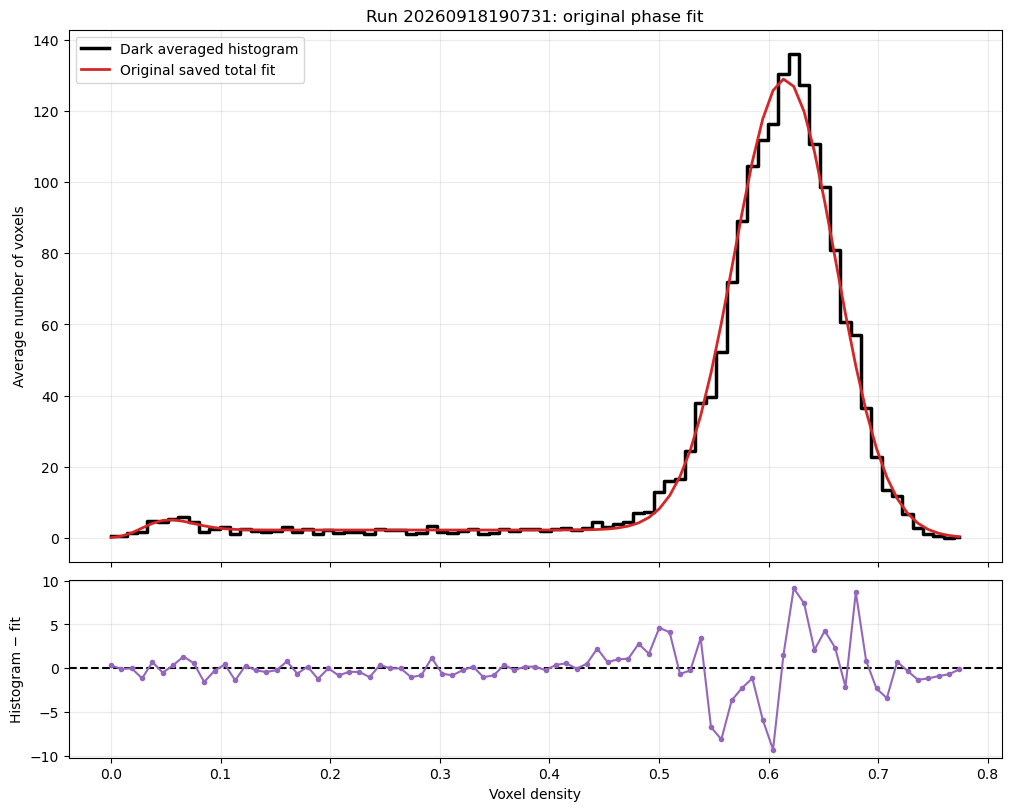

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from md_Helpers.voxel_fit import averaged_trajectory_voxel_histogram


import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run


run = open_run("20260918190731")
saved_fit = run._phase_fit_attributes()

required = ["density_axis", "observed_counts", "model_counts"]
missing = [key for key in required if key not in saved_fit]
if missing:
    raise KeyError(
        f"This run does not contain the original saved fit arrays: {missing}"
    )

density = np.asarray(saved_fit["density_axis"], dtype=float)
observed = np.asarray(saved_fit["observed_counts"], dtype=float)
model = np.asarray(saved_fit["model_counts"], dtype=float)

if not (len(density) == len(observed) == len(model)):
    raise ValueError("Saved histogram and fit arrays have different lengths.")

residual = observed - model

fig, (ax_fit, ax_resid) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

ax_fit.step(
    density, observed,
    where="mid", color="black", linewidth=2.5,
    label="Dark averaged histogram",
)
ax_fit.plot(
    density, model,
    color="tab:red", linewidth=2,
    label="Original saved total fit",
)
ax_fit.set_ylabel("Average number of voxels")
ax_fit.set_title(f"Run {run.run_id}: original phase fit")
ax_fit.grid(alpha=0.25)
ax_fit.legend()

ax_resid.axhline(0, color="black", linestyle="--")
ax_resid.plot(density, residual, "o-", markersize=3, color="tab:purple")
ax_resid.set_xlabel("Voxel density")
ax_resid.set_ylabel("Histogram − fit")
ax_resid.grid(alpha=0.25)

plt.show()

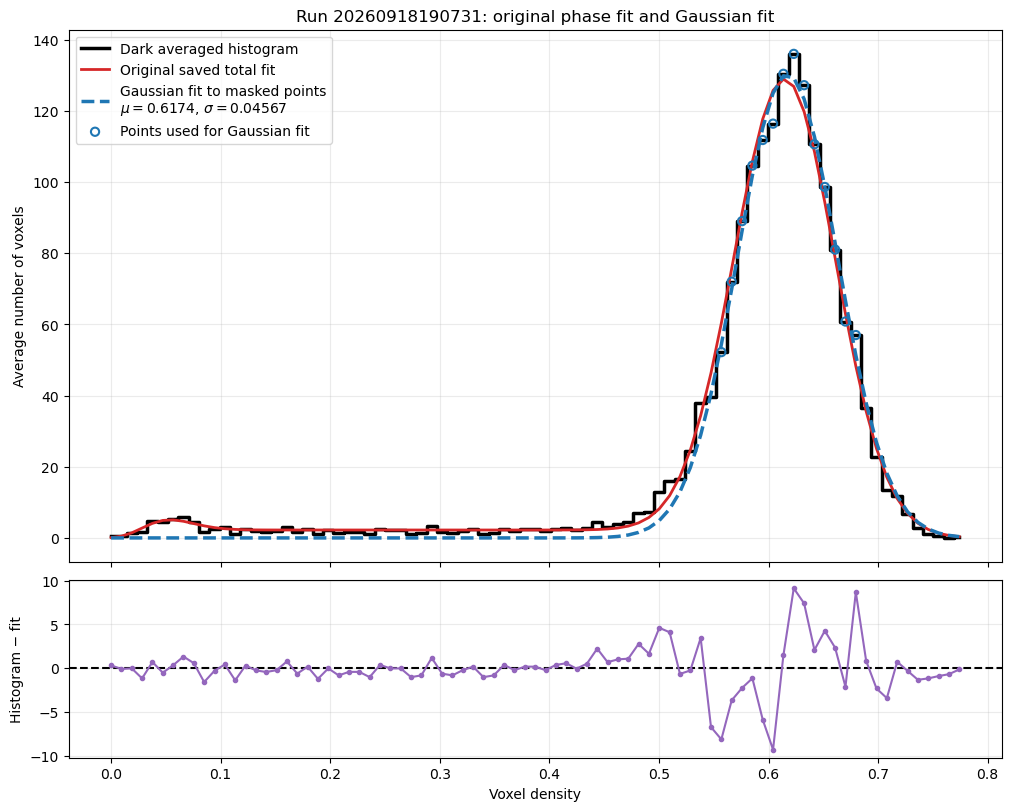

Gaussian amplitude = 130.28635
Gaussian mean      = 0.61735099
Gaussian sigma     = 0.045669029
Points used        = 14


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import importlib
import md_Helpers

importlib.reload(md_Helpers)
from md_Helpers import open_run


# Gaussian with a freely fitted amplitude, mean, and standard deviation
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


run = open_run("20260918190731")
saved_fit = run._phase_fit_attributes()

required = [
    "density_axis",
    "observed_counts",
    "model_counts",
    "liquid_counts",
    "rho_liquid",
]
missing = [key for key in required if key not in saved_fit]
if missing:
    raise KeyError(
        f"This run does not contain the required saved fit data: {missing}"
    )

density = np.asarray(saved_fit["density_axis"], dtype=float)
observed = np.asarray(saved_fit["observed_counts"], dtype=float)
model = np.asarray(saved_fit["model_counts"], dtype=float)
saved_liquid_gaussian = np.asarray(
    saved_fit["liquid_counts"], dtype=float
)
liquid_density = float(saved_fit["rho_liquid"])

if not (
    len(density)
    == len(observed)
    == len(model)
    == len(saved_liquid_gaussian)
):
    raise ValueError("Saved histogram and fit arrays have different lengths.")

# -------------------------------------------------------------------
# Mask used ONLY to fit the new Gaussian
# -------------------------------------------------------------------

saved_gaussian_amplitude = np.nanmax(saved_liquid_gaussian)

fit_mask = (
    np.isfinite(density)
    & np.isfinite(observed)
    & (density >= liquid_density / 2)
    & (observed > saved_gaussian_amplitude / 3)
)

x_fit = density[fit_mask]
y_fit = observed[fit_mask]

if len(x_fit) < 3:
    raise ValueError(
        "Fewer than three histogram points satisfy the Gaussian-fit mask."
    )

# Initial parameter estimates
amplitude_guess = float(np.max(y_fit))
mean_guess = float(x_fit[np.argmax(y_fit)])

weights = np.clip(y_fit, 0, None)
if np.sum(weights) > 0:
    sigma_guess = np.sqrt(
        np.sum(weights * (x_fit - mean_guess) ** 2) / np.sum(weights)
    )
else:
    sigma_guess = np.std(x_fit)

positive_spacing = np.diff(np.unique(density))
positive_spacing = positive_spacing[positive_spacing > 0]
minimum_sigma = (
    float(np.min(positive_spacing)) / 10
    if len(positive_spacing)
    else 1e-8
)

if not np.isfinite(sigma_guess) or sigma_guess <= minimum_sigma:
    sigma_guess = max(np.ptp(x_fit) / 4, minimum_sigma)

# Fit only the masked histogram points
gaussian_parameters, gaussian_covariance = curve_fit(
    gaussian,
    x_fit,
    y_fit,
    p0=[amplitude_guess, mean_guess, sigma_guess],
    bounds=(
        [0, np.min(density), minimum_sigma],
        [np.inf, np.max(density), np.inf],
    ),
    maxfev=100000,
)

gaussian_amplitude, gaussian_mean, gaussian_sigma = gaussian_parameters

# Evaluate the new Gaussian over the ENTIRE density axis
gaussian_full = gaussian(
    density,
    gaussian_amplitude,
    gaussian_mean,
    gaussian_sigma,
)

# Residual remains the original histogram minus the original saved fit
residual = observed - model

fig, (ax_fit, ax_resid) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

ax_fit.step(
    density,
    observed,
    where="mid",
    color="black",
    linewidth=2.5,
    label="Dark averaged histogram",
)

ax_fit.plot(
    density,
    model,
    color="tab:red",
    linewidth=2,
    label="Original saved total fit",
)

# Plot the newly fitted Gaussian everywhere, including outside the mask
ax_fit.plot(
    density,
    gaussian_full,
    color="tab:blue",
    linestyle="--",
    linewidth=2.5,
    label=(
        "Gaussian fit to masked points\n"
        rf"$\mu={gaussian_mean:.4g}$, "
        rf"$\sigma={gaussian_sigma:.4g}$"
    ),
)

# Show which histogram points were used for the Gaussian fit
ax_fit.scatter(
    x_fit,
    y_fit,
    s=35,
    facecolors="none",
    edgecolors="tab:blue",
    linewidths=1.5,
    zorder=5,
    label="Points used for Gaussian fit",
)

ax_fit.set_ylabel("Average number of voxels")
ax_fit.set_title(f"Run {run.run_id}: original phase fit and Gaussian fit")
ax_fit.grid(alpha=0.25)
ax_fit.legend()

ax_resid.axhline(0, color="black", linestyle="--")
ax_resid.plot(
    density,
    residual,
    "o-",
    markersize=3,
    color="tab:purple",
)
ax_resid.set_xlabel("Voxel density")
ax_resid.set_ylabel("Histogram − fit")
ax_resid.grid(alpha=0.25)

# Optional axis limits:
# ax_fit.set_xlim(0.4, 1.0)
# ax_fit.set_ylim(0, 100)
# ax_resid.set_ylim(-10, 10)

plt.show()

print(f"Gaussian amplitude = {gaussian_amplitude:.8g}")
print(f"Gaussian mean      = {gaussian_mean:.8g}")
print(f"Gaussian sigma     = {gaussian_sigma:.8g}")
print(f"Points used        = {fit_mask.sum()}")

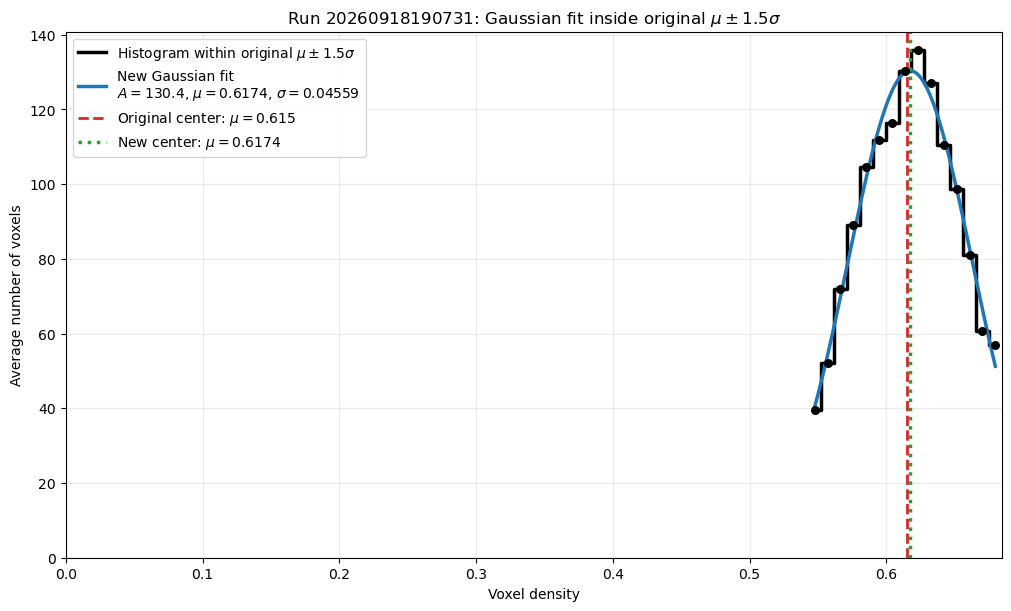

Original mean:  0.6149509
Original sigma: 0.046246352
Mask limits:    [0.54558137, 0.68432043]
New amplitude:  130.35324
New mean:       0.61738736
New sigma:      0.045586909


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import importlib
import md_Helpers

importlib.reload(md_Helpers)
from md_Helpers import open_run


# 1.0 = original mean ± 1 sigma
# 2.0 = original mean ± 2 sigma
N_SIGMA = 1.5


def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


run = open_run("20260918190731")
saved_fit = run._phase_fit_attributes()

required = [
    "density_axis",
    "observed_counts",
    "liquid_counts",
    "rho_liquid",
]
missing = [key for key in required if key not in saved_fit]
if missing:
    raise KeyError(f"Run is missing required saved-fit data: {missing}")

density = np.asarray(saved_fit["density_axis"], dtype=float)
observed = np.asarray(saved_fit["observed_counts"], dtype=float)
original_liquid_fit = np.asarray(saved_fit["liquid_counts"], dtype=float)

if not (len(density) == len(observed) == len(original_liquid_fit)):
    raise ValueError("Saved fit arrays have different lengths.")

# Original Gaussian center
original_mean = float(saved_fit["rho_liquid"])

# Original Gaussian standard deviation
original_weights = np.clip(original_liquid_fit, 0, None)

if np.sum(original_weights) <= 0:
    raise ValueError("The saved liquid-fit curve has no positive weight.")

original_sigma = np.sqrt(
    np.sum(
        original_weights * (density - original_mean) ** 2
    ) / np.sum(original_weights)
)

# Mask limits from the original fit
x_min = original_mean - N_SIGMA * original_sigma
x_max = original_mean + N_SIGMA * original_sigma

mask = (
    np.isfinite(density)
    & np.isfinite(observed)
    & (density >= x_min)
    & (density <= x_max)
)

x_masked = density[mask]
y_masked = observed[mask]

if len(x_masked) < 3:
    raise ValueError("Fewer than three points fall inside the sigma mask.")

# Initial estimates for the new Gaussian fit
amplitude_guess = float(np.max(y_masked))
mean_guess = float(x_masked[np.argmax(y_masked)])

masked_weights = np.clip(y_masked, 0, None)
if np.sum(masked_weights) > 0:
    sigma_guess = np.sqrt(
        np.sum(
            masked_weights * (x_masked - mean_guess) ** 2
        ) / np.sum(masked_weights)
    )
else:
    sigma_guess = original_sigma

spacing = np.diff(np.unique(x_masked))
spacing = spacing[spacing > 0]
minimum_sigma = (
    float(np.min(spacing)) / 10
    if len(spacing)
    else 1e-8
)

if not np.isfinite(sigma_guess) or sigma_guess <= minimum_sigma:
    sigma_guess = original_sigma

# New Gaussian fit using only the masked data
parameters, covariance = curve_fit(
    gaussian,
    x_masked,
    y_masked,
    p0=[amplitude_guess, mean_guess, sigma_guess],
    bounds=(
        [0, x_min, minimum_sigma],
        [np.inf, x_max, np.inf],
    ),
    maxfev=100000,
)

new_amplitude, new_mean, new_sigma = parameters

x_gaussian = np.linspace(x_masked.min(), x_masked.max(), 500)
y_gaussian = gaussian(
    x_gaussian,
    new_amplitude,
    new_mean,
    new_sigma,
)

fig, ax = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True,
)

ax.step(
    x_masked,
    y_masked,
    where="mid",
    color="black",
    linewidth=2.5,
    label=rf"Histogram within original $\mu \pm {N_SIGMA:g}\sigma$",
)

ax.scatter(
    x_masked,
    y_masked,
    s=30,
    color="black",
    zorder=3,
)

ax.plot(
    x_gaussian,
    y_gaussian,
    color="tab:blue",
    linewidth=2.5,
    label=(
        "New Gaussian fit\n"
        rf"$A={new_amplitude:.4g}$, "
        rf"$\mu={new_mean:.4g}$, "
        rf"$\sigma={new_sigma:.4g}$"
    ),
)

# Vertical line at the original Gaussian center
ax.axvline(
    original_mean,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=rf"Original center: $\mu={original_mean:.4g}$",
)

# Vertical line at the new Gaussian center
ax.axvline(
    new_mean,
    color="tab:green",
    linestyle=":",
    linewidth=2.5,
    label=rf"New center: $\mu={new_mean:.4g}$",
)

ax.set_xlim(x_min, x_max)
ax.set_xlabel("Voxel density")
ax.set_ylabel("Average number of voxels")
ax.set_title(
    f"Run {run.run_id}: Gaussian fit inside original "
    rf"$\mu \pm {N_SIGMA:g}\sigma$"
)
ax.grid(alpha=0.25)
ax.legend()

ax.set_xlim(0, None)
ax.set_ylim(0, None)

plt.show()

print(f"Original mean:  {original_mean:.8g}")
print(f"Original sigma: {original_sigma:.8g}")
print(f"Mask limits:    [{x_min:.8g}, {x_max:.8g}]")
print(f"New amplitude:  {new_amplitude:.8g}")
print(f"New mean:       {new_mean:.8g}")
print(f"New sigma:      {new_sigma:.8g}")

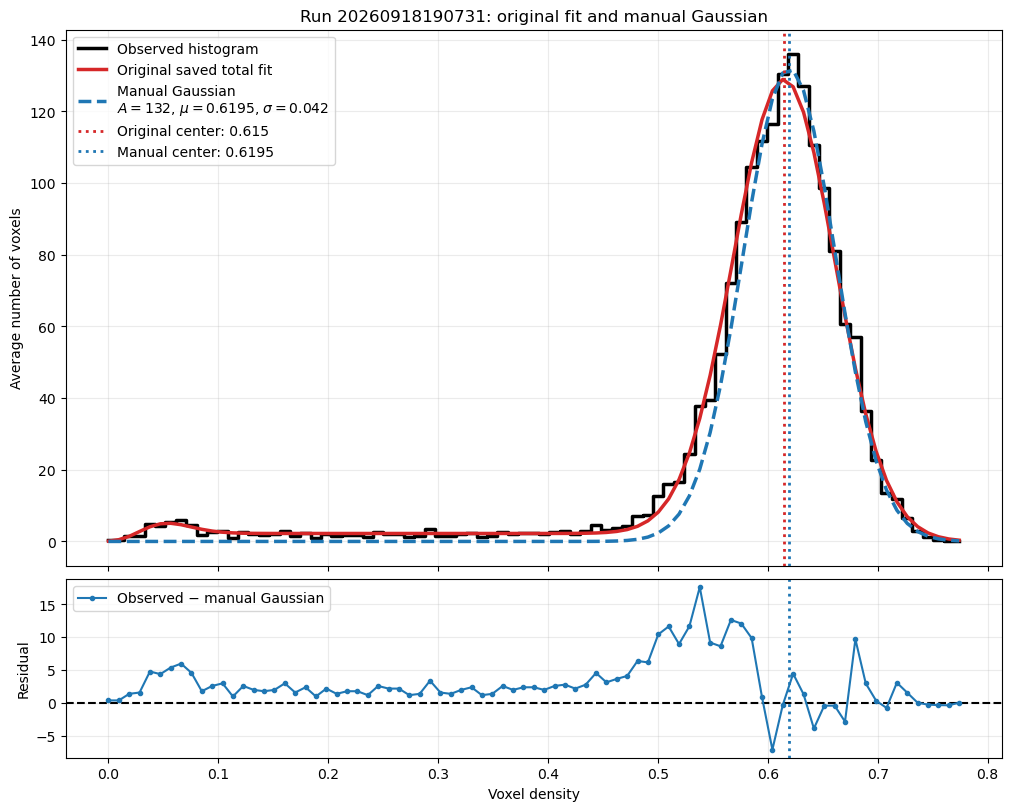

Original liquid Gaussian:
  amplitude = 127.80771
  mean      = 0.6149509
  sigma     = 0.046246352

Manual Gaussian:
  amplitude = 132
  mean      = 0.6195
  sigma     = 0.042


In [29]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import md_Helpers

importlib.reload(md_Helpers)
from md_Helpers import open_run


def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


run = open_run("20260918190731")
saved_fit = run._phase_fit_attributes()

required = [
    "density_axis",
    "observed_counts",
    "model_counts",
    "liquid_counts",
    "rho_liquid",
]
missing = [key for key in required if key not in saved_fit]
if missing:
    raise KeyError(f"Run is missing required saved-fit data: {missing}")

density = np.asarray(saved_fit["density_axis"], dtype=float)
observed = np.asarray(saved_fit["observed_counts"], dtype=float)
original_model = np.asarray(saved_fit["model_counts"], dtype=float)
original_liquid_fit = np.asarray(saved_fit["liquid_counts"], dtype=float)
original_mean = float(saved_fit["rho_liquid"])

if not (
    len(density)
    == len(observed)
    == len(original_model)
    == len(original_liquid_fit)
):
    raise ValueError("Saved histogram and fit arrays have different lengths.")

# Estimate the original liquid Gaussian sigma
original_weights = np.clip(original_liquid_fit, 0, None)

if np.sum(original_weights) <= 0:
    raise ValueError("The original liquid fit has no positive values.")

original_sigma = np.sqrt(
    np.sum(
        original_weights * (density - original_mean) ** 2
    ) / np.sum(original_weights)
)

original_amplitude = float(np.nanmax(original_liquid_fit))


# ================================================================
# EDIT THESE THREE VALUES TO MANUALLY ADJUST YOUR GAUSSIAN
# ================================================================


manual_amplitude = 132
manual_mean = 0.6195
manual_sigma = 0.042


if manual_amplitude < 0:
    raise ValueError("manual_amplitude must be nonnegative.")

if manual_sigma <= 0:
    raise ValueError("manual_sigma must be greater than zero.")

# Evaluate the manual Gaussian
manual_gaussian = gaussian(
    density,
    manual_amplitude,
    manual_mean,
    manual_sigma,
)

# Residual for the manual Gaussian
manual_residual = observed - manual_gaussian


fig, (ax_fit, ax_resid) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

# Observed histogram
ax_fit.step(
    density,
    observed,
    where="mid",
    color="black",
    linewidth=2.5,
    label="Observed histogram",
)

# Original saved total fit
ax_fit.plot(
    density,
    original_model,
    color="tab:red",
    linewidth=2.5,
    label="Original saved total fit",
)

# Manually adjusted Gaussian
ax_fit.plot(
    density,
    manual_gaussian,
    color="tab:blue",
    linestyle="--",
    linewidth=2.5,
    label=(
        "Manual Gaussian\n"
        rf"$A={manual_amplitude:.4g}$, "
        rf"$\mu={manual_mean:.4g}$, "
        rf"$\sigma={manual_sigma:.4g}$"
    ),
)

# Original Gaussian center
ax_fit.axvline(
    original_mean,
    color="tab:red",
    linestyle=":",
    linewidth=2,
    label=rf"Original center: {original_mean:.4g}",
)

# Manual Gaussian center
ax_fit.axvline(
    manual_mean,
    color="tab:blue",
    linestyle=":",
    linewidth=2,
    label=rf"Manual center: {manual_mean:.4g}",
)

ax_fit.set_ylabel("Average number of voxels")
ax_fit.set_title(
    f"Run {run.run_id}: original fit and manual Gaussian"
)
ax_fit.grid(alpha=0.25)
ax_fit.legend()


# Manual Gaussian residual
ax_resid.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
)

ax_resid.plot(
    density,
    manual_residual,
    "o-",
    color="tab:blue",
    markersize=3,
    linewidth=1.5,
    label="Observed − manual Gaussian",
)

ax_resid.axvline(
    manual_mean,
    color="tab:blue",
    linestyle=":",
    linewidth=2,
)

ax_resid.set_xlabel("Voxel density")
ax_resid.set_ylabel("Residual")
ax_resid.grid(alpha=0.25)
ax_resid.legend()


# Optional axis limits:
# ax_fit.set_xlim(0.4, 1.0)
# ax_fit.set_ylim(0, 100)
# ax_resid.set_ylim(-10, 10)

plt.show()

print("Original liquid Gaussian:")
print(f"  amplitude = {original_amplitude:.8g}")
print(f"  mean      = {original_mean:.8g}")
print(f"  sigma     = {original_sigma:.8g}")

print("\nManual Gaussian:")
print(f"  amplitude = {manual_amplitude:.8g}")
print(f"  mean      = {manual_mean:.8g}")
print(f"  sigma     = {manual_sigma:.8g}")